In [2]:
import sportsdataverse.nfl as sdv
import numpy as np
import pandas as pd
import time
import requests
import random
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE, SelectKBest, f_classif, mutual_info_classif, SelectFromModel
from hyperopt import hp, fmin, tpe, Trials

In [3]:
pd.set_option('display.max_columns', None)
pd.reset_option('display.max_rows')
pd.reset_option('display.max_colwidth')

In [4]:
def import_games(start_year, end_year=None):
    years = range(start_year, end_year + 1) if end_year else [start_year]
    all_games = pd.concat([sdv.espn_nfl_schedule(dates=year, return_as_pandas=True) for year in years], axis=0, ignore_index=True)
    return all_games

In [8]:
"""
main_df = import_games(2002, 2023)
main_df.to_json(f'nfl_2002_2023.json', orient='records')
"""

,id,uid,date,attendance,time_valid,neutral_site,conference_competition,play_by_play_available,recent,start_date,broadcast,highlights,notes_type,notes_headline,broadcast_market,broadcast_name,type_id,type_abbreviation,venue_id,venue_full_name,venue_address_city,venue_address_state,venue_address_country,venue_indoor,status_clock,status_display_clock,status_period,status_type_id,status_type_name,status_type_state,status_type_completed,status_type_description,status_type_detail,status_type_short_detail,status_is_tbd_flex,format_regulation_periods,home_id,home_uid,home_location,home_name,home_abbreviation,home_display_name,home_short_display_name,home_color,home_alternate_color,home_is_active,home_venue_id,home_logo,home_score,home_winner,home_current_rank,home_linescores,home_records,away_id,away_uid,away_location,away_name,away_abbreviation,away_display_name,away_short_display_name,away_color,away_alternate_color,away_is_active,away_venue_id,away_logo,away_score,away_winner,away_current_rank,away_linescores,away_records,game_id,season,season_type,week,status_type_alt_detail
30,401772971,s:20~l:28~e:401772971~c:401772971,2025-08-01T00:00Z,0,True,True,False,False,False,2025-08-01T00:00Z,NBC/Peacock,[],event,Hall of Fame Game,national,NBC,1,STD,3718,Tom Benson Hall of Fame Stadium,Canton,OH,USA,False,0.0,0:00,0,1,STATUS_SCHEDULED,pre,False,Scheduled,"Thu, July 31st at 8:00 PM EDT",7/31 - 8:00 PM EDT,False,4,8,s:20~l:28~t:8,Detroit,Lions,DET,Detroit Lions,Lions,0076b6,bbbbbb,True,3727,https://a.espncdn.com/i/teamlogos/nfl/500/scor...,0,None,99,"[{'displayValue': None, 'period': None, 'value...","[{'abbreviation': 'Game', 'name': 'overall', '...",24,s:20~l:28~t:24,Los Angeles,Chargers,LAC,Los Angeles Chargers,Chargers,0080c6,ffc20e,True,538,https://a.espncdn.com/i/teamlogos/nfl/500/scor...,0,None,99,"[{'displayValue': None, 'period': None, 'value...","[{'abbreviation': 'Game', 'name': 'overall', '...",401772971,2025,1,1,None
31,401773001,s:20~l:28~e:401773001~c:401773001,2025-08-07T23:00Z,0,True,False,False,False,False,2025-08-07T23:00Z,NFL Net,[],,,national,NFL Net,1,STD,3814,M&T Bank Stadium,Baltimore,MD,USA,False,0.0,0:00,0,1,STATUS_SCHEDULED,pre,False,Scheduled,"Thu, August 7th at 7:00 PM EDT",8/7 - 7:00 PM EDT,False,4,33,s:20~l:28~t:33,Baltimore,Ravens,BAL,Baltimore Ravens,Ravens,29126f,000000,True,3814,https://a.espncdn.com/i/teamlogos/nfl/500/scor...,0,None,99,"[{'displayValue': None, 'period': None, 'value...","[{'abbreviation': 'Game', 'name': 'overall', '...",11,s:20~l:28~t:11,Indianapolis,Colts,IND,Indianapolis Colts,Colts,003b75,ffffff,True,3812,https://a.espncdn.com/i/teamlogos/nfl/500/scor...,0,None,99,"[{'displayValue': None, 'period': None, 'value...","[{'abbreviation': 'Game', 'name': 'overall', '...",401773001,2025,1,2,None
32,401773005,s:20~l:28~e:401773005~c:401773005,2025-08-07T23:30Z,0,True,False,False,False,False,2025-08-07T23:30Z,,[],,,,,1,STD,3806,Lincoln Financial Field,Philadelphia,PA,USA,False,0.0,0:00,0,1,STATUS_SCHEDULED,pre,False,Scheduled,"Thu, August 7th at 7:30 PM EDT",8/7 - 7:30 PM EDT,False,4,21,s:20~l:28~t:21,Philadelphia,Eagles,PHI,Philadelphia Eagles,Eagles,06424d,000000,True,3806,https://a.espncdn.com/i/teamlogos/nfl/500/scor...,0,None,99,"[{'displayValue': None, 'period': None, 'value...","[{'abbreviation': 'Game', 'name': 'overall', '...",4,s:20~l:28~t:4,Cincinnati,Bengals,CIN,Cincinnati Bengals,Bengals,fb4f14,000000,True,3874,https://a.espncdn.com/i/teamlogos/nfl/500/scor...,0,None,99,"[{'displayValue': None, 'period': None, 'value...","[{'abbreviation': 'Game', 'name': 'overall', '...",401773005,2025,1,2,None
33,401774568,s:20~l:28~e:401774568~c:401774568,2025-08-08T02:00Z,0,True,False,False,False,False,2025-08-08T02:00Z,NFL Net,[],,,national,NFL Net,1,STD,3673,Lumen Field,Seattle,WA,USA,False,0.0,0:00,0,1,STATUS_SCHEDULED,pre,False,Scheduled,"Thu, August 7th at 10:00 PM EDT",8/7 - 10:00 PM EDT,False,4,26,s:20~l:28~t:26,Seattle,Seahawks,SEA,Seattle Seahawks,Seahawks,002a5c,69be28,True,3673,h

In [7]:
main_df = pd.read_json(f'nfl_2002_2023.json')
main_df

,id,uid,date,attendance,time_valid,neutral_site,conference_competition,play_by_play_available,recent,start_date,broadcast,highlights,notes_type,notes_headline,broadcast_market,broadcast_name,type_id,type_abbreviation,status_clock,status_display_clock,status_period,status_type_id,status_type_name,status_type_state,status_type_completed,status_type_description,status_type_detail,status_type_short_detail,status_is_tbd_flex,format_regulation_periods,home_id,home_uid,home_location,home_name,home_abbreviation,home_display_name,home_short_display_name,home_color,home_alternate_color,home_is_active,home_venue_id,home_logo,home_score,home_winner,home_current_rank,home_linescores,home_records,away_id,away_uid,away_location,away_name,away_abbreviation,away_display_name,away_short_display_name,away_color,away_alternate_color,away_is_active,away_venue_id,away_logo,away_score,away_winner,away_current_rank,away_linescores,away_records,game_id,season,season_type,week,venue_id,venue_full_name,venue_address_city,venue_address_state,venue_address_country,venue_indoor,status_type_alt_detail
0,220106011,s:20~l:28~e:220106011~c:220106011,2002-01-06 17:00:00+00:00,56192,True,False,False,True,False,2002-01-06T17:00Z,CBS,[],,,national,CBS,1,STD,0,0:00,4,3,STATUS_FINAL,post,True,Final,Final,Final,False,4,11,s:20~l:28~t:11,Indianapolis,Colts,IND,Indianapolis Colts,Colts,00417E,ffffff,True,3812.0,https://a.espncdn.com/i/teamlogos/nfl/500/scor...,29,1.0,99,"[{'value': 9.0}, {'value': 10.0}, {'value': 3....","[{'abbreviation': 'Game', 'name': 'overall', '...",7,s:20~l:28~t:7,Denver,Broncos,DEN,Denver Broncos,Broncos,002E4D,fc4c02,True,3937.0,https://a.espncdn.com/i/teamlogos/nfl/500/scor...,10,0.0,99,"[{'value': 0.0}, {'value': 7.0}, {'value': 3.0...","[{'abbreviation': 'Game', 'name': 'overall', '...",220106011,2001,2,17.0,NaN,None,None,None,None,NaN,None
1,220106003,s:20~l:28~e:220106003~c:220106003,2002-01-06 18:00:00+00:00,66944,True,False,False,True,False,2002-01-06T18:00Z,CBS,[],,,national,CBS,1,STD,0,0:00,4,3,STATUS_FINAL,post,True,Final,Final,Final,False,4,3,s:20~l:28~t:3,Chicago,Bears,CHI,Chicago Bears,Bears,152644,e64100,True,3933.0,https://a.espncdn.com/i/teamlogos/nfl/500/scor...,33,1.0,99,"[{'value': 3.0}, {'value': 10.0}, {'value': 10...","[{'abbreviation': 'Game', 'name': 'overall', '...",30,s:20~l:28~t:30,Jacksonville,Jaguars,JAX,Jacksonville Jaguars,Jaguars,00839C,d7a22a,True,3712.0,https://a.espncdn.com/i/teamlogos/nfl/500/scor...,13,0.0,99,"[{'value': 0.0}, {'value': 0.0}, {'value': 6.0...","[{'abbreviation': 'Game', 'name': 'overall', '...",220106003,2001,2,17.0,NaN,None,None,None,None,NaN,None
2,220106008,s:20~l:28~e:220106008~c:220106008,2002-01-06 18:00:00+00:00,77512,True,False,False,True,False,2002-01-06T18:00Z,FOX,[],,,national,FOX,1,STD,0,0:00,4,3,STATUS_FINAL,post,True,Final,Final,Final,False,4,8,s:20~l:28~t:8,Detroit,Lions,DET,Detroit Lions,Lions,035C98,bbbbbb,True,3727.0,https://a.espncdn.com/i/teamlogos/nfl/500/scor...,15,1.0,99,"[{'value': 0.0}, {'value': 6.0}, {'value': 3.0...","[{'abbreviation': 'Game', 'name': 'overall', '...",6,s:20~l:28~t:6,Dallas,Cowboys,DAL,Dallas Cowboys,Cowboys,002E4D,b0b7bc,True,3687.0,https://a.espncdn.com/i/teamlogos/nfl/500/scor...,10,0.0,99,"[{'value': 0.0}, {'value': 7.0}, {'value': 0.0...","[{'abbreviation': 'Game', 'name': 'overall', '...",220106008,2001,2,17.0,NaN,None,None,None,None,NaN,None
3,220106010,s:20~l:28~e:220106010~c:220106010,2002-01-06 18:00:00+00:00,68798,True,False,False,True,False,2002-01-06T18:00Z,CBS,[],,,national,CBS,1,STD,0,0:00,4,3,STATUS_FINAL,post,True,Final,Final,Final,False,4,10,s:20~l:28~t:10,Tennessee,Titans,TEN,Tennessee Titans,Titans,2F95DD,002a5c,True,3810.0,https://a.espncdn.com/i/teamlogos/nfl/500/scor...,21,0.0,99,"[{'value': 7.0}, {'value': 7.0}, {'value': 7.0...","[{'abbreviation': 'Game', 'name': 'overall', '...",4,s:20~l:28~t:4,Cincinnati,Bengals,CIN,Cincinnati Bengals,Bengals,FF2700,000000,True,3874.0,https://a.espncdn.com/i/teamlogos/nfl/500/scor...,23

In [8]:
pd.set_option('display.max_colwidth', 1000)
pd.set_option('display.max_columns', None)

In [9]:
main_df.columns

Index(['id', 'uid', 'date', 'attendance', 'time_valid', 'neutral_site',
       'conference_competition', 'play_by_play_available', 'recent',
       'start_date', 'broadcast', 'highlights', 'notes_type', 'notes_headline',
       'broadcast_market', 'broadcast_name', 'type_id', 'type_abbreviation',
       'status_clock', 'status_display_clock', 'status_period',
       'status_type_id', 'status_type_name', 'status_type_state',
       'status_type_completed', 'status_type_description',
       'status_type_detail', 'status_type_short_detail', 'status_is_tbd_flex',
       'format_regulation_periods', 'home_id', 'home_uid', 'home_location',
       'home_name', 'home_abbreviation', 'home_display_name',
       'home_short_display_name', 'home_color', 'home_alternate_color',
       'home_is_active', 'home_venue_id', 'home_logo', 'home_score',
       'home_winner', 'home_current_rank', 'home_linescores', 'home_records',
       'away_id', 'away_uid', 'away_location', 'away_name',
       'away_abbr

In [10]:
def get_game_stats(team, start_year=2002, end_year=2024):
    team = team.lower()
    years = range(start_year, end_year + 1) if end_year else [start_year]
    team_df = pd.DataFrame()

    for year in years:
        url = f'https://www.pro-football-reference.com/teams/{team}/{year}.htm'

        try:
            df = pd.read_html(url)[1]
        except:
            return None

        team_df = pd.concat([team_df, df], axis=0, ignore_index=True)
        time.sleep(random.uniform(3.1, 3.3))

    return team_df

In [11]:
team_list = main_df['home_abbreviation'].unique().tolist()

"""
teams_dict = {}
for team in team_list:
    teams_dict[team] = get_game_stats(team, 2002, 2024)
    teams_dict[team].to_json(f'./team_jsons2/{teems[team]}_2002_2024.json')

team_list
"""

"\nteams_dict = {}\nfor team in team_list:\n    teams_dict[team] = get_game_stats(team, 2002, 2024)\n    teams_dict[team].to_json(f'./team_jsons2/{teems[team]}_2002_2024.json')\n\nteam_list\n"

In [12]:
"""
for team in teams_dict.keys():
    try:
        teams_dict[team].to_json(f'./team_jsons2/{team}_2002_2024.json')
    except:
        continue
"""

"\nfor team in teams_dict.keys():\n    try:\n        teams_dict[team].to_json(f'./team_jsons2/{team}_2002_2024.json')\n    except:\n        continue\n"

In [13]:
"""
teems = {'CLT':'IND', 'OTI':'TEN', 'NOR': 'NO', 'WAS':'WSH', 'RAM': 'LAR', 'TAM':'TB', 'RAV':'BAL', 'GNB':'GB', 'NWE':'NE', 'SFO':'SF', 'KAN':'KC', 'CRD':'ARI', 'HTX':'HOU', 'SDG':'LAC', 'RAI':'LV'}
for team in teems:
    get_game_stats(team).to_json(f'./team_jsons2/{teems[team]}_2002_2024.json')
"""

"\nteems = {'CLT':'IND', 'OTI':'TEN', 'NOR': 'NO', 'WAS':'WSH', 'RAM': 'LAR', 'TAM':'TB', 'RAV':'BAL', 'GNB':'GB', 'NWE':'NE', 'SFO':'SF', 'KAN':'KC', 'CRD':'ARI', 'HTX':'HOU', 'SDG':'LAC', 'RAI':'LV'}\nfor team in teems:\n    get_game_stats(team).to_json(f'./team_jsons2/{teems[team]}_2002_2024.json')\n"

In [14]:
def get_team_jsons(team_dict):
    for team, df in teams_dict.items():
        if isinstance(df, pd.DataFrame):
            df.to_json(f'./team_jsons/{team}_2002_2024.json')
        else:
            print(f"Skipping {team}: Data is None or not a DataFrame")

In [15]:
def assign_year(df, team, start_year=2001):
    df = df.rename(columns={'(\'Unnamed: 0_level_0\', \'Week\')': 'Week', '(\'Unnamed: 1_level_0\', \'Day\')': 'Day', "('Unnamed: 4_level_0', 'Unnamed: 4_level_1')": "boxscore",
                            "('Unnamed: 9_level_0', 'Opp')": "Opponents", "('Score', 'Tm')": "Home_Score",	"('Score', 'Opp')": "Away_Score",
                            "('Offense', '1stD')": "Offensive_1sts", "('Offense', 'TotYd')": "Offense_Total_Yrds", "('Offense', 'PassY')": "Offense_Pass_Yrds",
                            "('Offense', 'RushY')": "Offense_Rush_Yrds", "('Offense', 'TO')": "Turnovers_Lost", "('Defense', '1stD')": "Defense_1st_Allowed",
                            "('Defense', 'TotYd')": "Total_Yrds_Allowed", "('Defense', 'PassY')": "Pass_Yrds_Allowed", "('Defense', 'RushY')": "Rush_Yrds_Allowed",
                            "('Defense', 'TO')": "Turnovers_Gained", "('Expected Points', 'Offense')": "Offense_Expected_Points",
                            "('Expected Points', 'Defense')": "Defense_Expected_Points", "('Expected Points', 'Sp. Tms')": "Spteams_Expected_Points"})
    df.drop(columns=df.columns[[2, 3, 5, 6, 7, 8]], inplace=True)
    df['Week'] = df['Week'].replace({'Wild Card': -1, 'Division': -2, 'Conf. Champ.': -3, 'SuperBowl': -4})
    df['Week'] = pd.to_numeric(df['Week'], errors='coerce')
    df['season_type'] = np.where(df['Week'] < 0, 3, 2)
    
    current_year = int(start_year)
    prev_week = 0
    years = []

    for week in df['Week']:
        if (week == 1) or ((prev_week == 17) and (week == 2) and (team == 'TB') and (current_year == 2016)):
            current_year += 1
        years.append(current_year)
        prev_week = week

    df["Year"] = years
    df['Team'] = team
    df.loc[(df['Year'] > 2008) & (df['Week'] == -4), 'Week'] = 5
    df['Week'] = df['Week'].abs()
    
    return df

In [16]:
"""
def assign_year(df, team, start_year=2001):
    df = df.rename(columns={'(\'Unnamed: 0_level_0\', \'Week\')': 'Week', '(\'Unnamed: 1_level_0\', \'Day\')': 'Day', 
                           '(\'Unnamed: 2_level_0\', \'Date\')': 'Date', '(\'Unnamed: 3_level_0\', \'Unnamed: 3_level_1\')': 'Time',
                           '(\'Unnamed: 5_level_0\', \'Unnamed: 5_level_1\')': 'Result', '(\'Unnamed: 6_level_0\', \'OT\')': 'OT',
                           '(\'Unnamed: 7_level_0\', \'Rec\')': 'Record', '(\'Unnamed: 8_level_0\', \'Unnamed: 8_level_1\')': '@'})
    df['Team'] = team
    df['Week'] = pd.to_numeric(df['Week'], errors='coerce')
    df['Week'] = df['Week'].fillna(0).astype(int)
    current_year = start_year
    years = []

    for week in df['Week']:
        if week == 1:
            current_year += 1
        years.append(current_year)

    df["Year"] = years
    return df
"""

'\ndef assign_year(df, team, start_year=2001):\n    df = df.rename(columns={\'(\'Unnamed: 0_level_0\', \'Week\')\': \'Week\', \'(\'Unnamed: 1_level_0\', \'Day\')\': \'Day\', \n                           \'(\'Unnamed: 2_level_0\', \'Date\')\': \'Date\', \'(\'Unnamed: 3_level_0\', \'Unnamed: 3_level_1\')\': \'Time\',\n                           \'(\'Unnamed: 5_level_0\', \'Unnamed: 5_level_1\')\': \'Result\', \'(\'Unnamed: 6_level_0\', \'OT\')\': \'OT\',\n                           \'(\'Unnamed: 7_level_0\', \'Rec\')\': \'Record\', \'(\'Unnamed: 8_level_0\', \'Unnamed: 8_level_1\')\': \'@\'})\n    df[\'Team\'] = team\n    df[\'Week\'] = pd.to_numeric(df[\'Week\'], errors=\'coerce\')\n    df[\'Week\'] = df[\'Week\'].fillna(0).astype(int)\n    current_year = start_year\n    years = []\n\n    for week in df[\'Week\']:\n        if week == 1:\n            current_year += 1\n        years.append(current_year)\n\n    df["Year"] = years\n    return df\n'

In [17]:
teams_dict = {}

for team in team_list:
    try:
        df = pd.read_json(f'./team_jsons2/{team}_2002_2024.json')
        df = assign_year(df, team)
        teams_dict[team] = df
    except:
        continue

In [18]:
teams_dict['NYJ'].head(25)

,Week,Day,boxscore,Opponents,Home_Score,Away_Score,Offensive_1sts,Offense_Total_Yrds,Offense_Pass_Yrds,Offense_Rush_Yrds,Turnovers_Lost,Defense_1st_Allowed,Total_Yrds_Allowed,Pass_Yrds_Allowed,Rush_Yrds_Allowed,Turnovers_Gained,Offense_Expected_Points,Defense_Expected_Points,Spteams_Expected_Points,season_type,Year,Team
0,1.0,Sun,boxscore,Buffalo Bills,37.0,31.0,18.0,266.0,193.0,73.0,1.0,26.0,384.0,242.0,142.0,3.0,-0.59,-3.16,7.81,2,2002,NYJ
1,2.0,Sun,boxscore,New England Patriots,7.0,44.0,9.0,200.0,168.0,32.0,2.0,24.0,432.0,269.0,163.0,2.0,-31.62,-12.36,7.88,2,2002,NYJ
2,3.0,Sun,boxscore,Miami Dolphins,3.0,30.0,13.0,189.0,131.0,58.0,4.0,21.0,394.0,183.0,211.0,NaN,-20.16,-12.81,5.63,2,2002,NYJ
3,4.0,Sun,boxscore,Jacksonville Jaguars,3.0,28.0,18.0,345.0,267.0,78.0,4.0,20.0,383.0,160.0,223.0,NaN,-15.39,-14.42,5.00,2,2002,NYJ
4,5.0,Sun,boxscore,Kansas City Chiefs,25.0,29.0,23.0,359.0,212.0,147.0,1.0,24.0,504.0,289.0,215.0,1.0,12.66,-17.92,-0.14,2,2002,NYJ
5,6.0,None,None,Bye Week,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2002,NYJ
6,7.0,Sun,boxscore,Minnesota Vikings,20.0,7.0,21.0,407.0,316.0,91.0,NaN,21.0,389.0,288.0,101.0,4.0,16.36,-3.93,-1.25,2,2002,NYJ
7,8.0,Sun,boxscore,Cleveland Browns,21.0,24.0,14.0,241.0,175.0,66.0,3.0,18.0,334.0,279.0,55.0,NaN,-4.46,-4.55,4.40,2,2002,NYJ
8,9.0,Sun,boxscore,San Diego Chargers,44.0,13.0,21.0,413.0,248.0,165.0,NaN,15.0,243.0,170.0,73.0,3.0,13.34,11.63,7.92,2,2002,NYJ
9,10.0,Sun,boxscore,Miami Dolphins,13.0,10.0,19.0,264.0,167.0,97.0,NaN,15.0,279.0,210.0,69.0,2.0,-2.58,8.54,-2.40,2,2002,NYJ


In [19]:
def adjust_record(record, team_type, winner):
    overall_summary = next((item['summary'] for item in record if item['name'] == 'overall'), None)
    home_summary = next((item['summary'] for item in record if item['name'] == 'Home'), None)
    road_summary = next((item['summary'] for item in record if item['name'] == 'Road'), None)

    def parse_summary(summary):
        if summary and '-' in summary:
            try:
                wins, losses = map(int, summary.split('-'))
                return wins, losses
            except ValueError:
                return None, None
        else:
            return None, None

    overall_wins, overall_losses = parse_summary(overall_summary)
    home_wins, home_losses = parse_summary(home_summary)
    road_wins, road_losses = parse_summary(road_summary)

    if team_type == "home":
        if winner:  # Home team won
            if home_wins is not None:
                home_wins -= 1  # Don't count this win for home team
            if overall_wins is not None:
                overall_wins -= 1  # Don't count this win for overall record
        else:  # Away team won
            if home_losses is not None:
                home_losses -= 1  # Home team lost, so adjust their loss count
            if overall_losses is not None:
                overall_losses -= 1  # Don't count this loss for overall record
    else:  # away team
        if winner:  # Away team won
            if road_wins is not None:
                road_wins -= 1  # Don't count this win for away team
            if overall_wins is not None:
                overall_wins -= 1  # Don't count this win for overall record
        else:  # Home team won
            if road_losses is not None:
                road_losses -= 1  # Away team lost, so adjust their loss count
            if overall_losses is not None:
                overall_losses -= 1  # Don't count this loss for overall record

    return overall_wins, overall_losses, home_wins, home_losses, road_wins, road_losses

In [20]:
def change_old_teams(df, team):
    df = df[df[team] != "AFC"]
    df = df[df[team] != "NFC"]
    df = df[df[team] != "RIC"]
    df = df[df[team] != "CTR"]
    df = df[df[team] != "IRV"]

    replace_dict = {'STL': 'LAR', 'OAK': 'LV', 'SD': 'LAC'}
    df[team] = df[team].replace(replace_dict)
    
    return df

In [21]:
def arrange_team_json(df, team):
    df = df.copy()
    df = df.dropna(subset=['Opponents'])
    df.rename(columns={"Team": "Home_Team"}, inplace=True)
    
    return df

In [22]:
tb_df = arrange_team_json(teams_dict['TB'], 'TB')
sea_df = arrange_team_json(teams_dict['SEA'], 'SEA')
tb_df[tb_df['Year'] == 2020]

,Week,Day,boxscore,Opponents,Home_Score,Away_Score,Offensive_1sts,Offense_Total_Yrds,Offense_Pass_Yrds,Offense_Rush_Yrds,Turnovers_Lost,Defense_1st_Allowed,Total_Yrds_Allowed,Pass_Yrds_Allowed,Rush_Yrds_Allowed,Turnovers_Gained,Offense_Expected_Points,Defense_Expected_Points,Spteams_Expected_Points,season_type,Year,Home_Team
313,1.0,Sun,boxscore,New Orleans Saints,23.0,34.0,23.0,310.0,224.0,86.0,3.0,18.0,271.0,189.0,82.0,NaN,0.48,-1.98,-11.57,2,2020,TB
314,2.0,Sun,boxscore,Carolina Panthers,31.0,17.0,20.0,339.0,217.0,122.0,2.0,24.0,427.0,340.0,87.0,4.0,7.61,-0.25,4.83,2,2020,TB
315,3.0,Sun,boxscore,Denver Broncos,28.0,10.0,17.0,353.0,285.0,68.0,NaN,13.0,226.0,184.0,42.0,2.0,7.71,10.72,0.99,2,2020,TB
316,4.0,Sun,boxscore,Los Angeles Chargers,38.0,31.0,28.0,484.0,369.0,115.0,1.0,15.0,324.0,278.0,46.0,2.0,12.95,-5.88,0.20,2,2020,TB
317,5.0,Thu,boxscore,Chicago Bears,19.0,20.0,18.0,339.0,233.0,106.0,1.0,18.0,243.0,208.0,35.0,1.0,-3.30,0.67,-1.05,2,2020,TB
318,6.0,Sun,boxscore,Green Bay Packers,38.0,10.0,21.0,324.0,166.0,158.0,NaN,13.0,201.0,107.0,94.0,2.0,15.29,21.73,-4.79,2,2020,TB
319,7.0,Sun,boxscore,Las Vegas Raiders,45.0,20.0,29.0,454.0,369.0,85.0,NaN,19.0,347.0,271.0,76.0,1.0,30.56,-1.69,-4.89,2,2020,TB
320,8.0,Mon,boxscore,New York Giants,25.0,23.0,23.0,344.0,263.0,81.0,1.0,24.0,357.0,256.0,101.0,2.0,5.01,-3.57,2.61,2,2020,TB
321,9.0,Sun,boxscore,New Orleans Saints,3.0,38.0,13.0,194.0,186.0,8.0,3.0,27.0,420.0,282.0,138.0,2.0,-19.57,-13.73,0.26,2,2020,TB
322,10.0,Sun,boxscore,Carolina Panthers,46.0,23.0,30.0,544.0,334.0,210.0,1.0,13.0,187.0,122.0,65.0,1.0,27.30,6.81,-11.18,2,2020,TB


In [23]:
"""
def get_rolling_df(df):
    numeric_cols = ['Home_Score', 'Away_Score','Offense_Total_Yrds', 'Offense_Pass_Yrds', 'Offense_Rush_Yrds', 
                'Turnovers_Lost', 'Total_Yrds_Allowed', 'Pass_Yrds_Allowed', 
                'Rush_Yrds_Allowed', 'Turnovers_Gained', 'Offense_Expected_Points', 
                'Defense_Expected_Points', 'Spteams_Expected_Points']

    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
    df['Year'] = df[]

    team_stats = df[['Home_Team', 'Year', 'Week', 'season_type'] + numeric_cols].copy()
    team_stats[numeric_cols] = (team_stats
                                     .groupby(['Home_Team', 'Year'])[numeric_cols]
                                     .expanding()
                                     .mean()
                                     .shift(1)
                                     .reset_index(level=[0,1], drop=True))

    return team_stats
"""

"\ndef get_rolling_df(df):\n    numeric_cols = ['Home_Score', 'Away_Score','Offense_Total_Yrds', 'Offense_Pass_Yrds', 'Offense_Rush_Yrds', \n                'Turnovers_Lost', 'Total_Yrds_Allowed', 'Pass_Yrds_Allowed', \n                'Rush_Yrds_Allowed', 'Turnovers_Gained', 'Offense_Expected_Points', \n                'Defense_Expected_Points', 'Spteams_Expected_Points']\n\n    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')\n    df['Year'] = df[]\n\n    team_stats = df[['Home_Team', 'Year', 'Week', 'season_type'] + numeric_cols].copy()\n    team_stats[numeric_cols] = (team_stats\n                                     .groupby(['Home_Team', 'Year'])[numeric_cols]\n                                     .expanding()\n                                     .mean()\n                                     .shift(1)\n                                     .reset_index(level=[0,1], drop=True))\n\n    return team_stats\n"

In [24]:
def get_rolling_df(df):
    numeric_cols = ['Home_Score', 'Away_Score', 'Offense_Total_Yrds', 'Offense_Pass_Yrds', 'Offense_Rush_Yrds', 
                    'Turnovers_Lost', 'Total_Yrds_Allowed', 'Pass_Yrds_Allowed', 
                    'Rush_Yrds_Allowed', 'Turnovers_Gained', 'Offense_Expected_Points', 
                    'Defense_Expected_Points', 'Spteams_Expected_Points', 'Offensive_1sts']

    team_stats = df.copy()
    
    team_stats[numeric_cols] = team_stats[numeric_cols].apply(pd.to_numeric, errors='coerce')
    
    team_stats = team_stats.sort_values(['Home_Team', 'Year'])
    
    rolling_stats = team_stats.copy()
    
    for col in numeric_cols:
        rolling_stats[col] = (
            team_stats
            .groupby(['Home_Team', 'Year'])[col]
            .transform(lambda x: x.rolling(window=4, min_periods=1).mean().shift(1))
        )
    
    first_week_mask = team_stats.duplicated(subset=['Home_Team', 'Year'], keep='first') == False
    rolling_stats.loc[first_week_mask, numeric_cols] = pd.NA
    
    team_stats[numeric_cols] = rolling_stats[numeric_cols]
    
    return team_stats

In [25]:
def update_elo(home_elo, away_elo, home_score, away_score, k_factor=30):
    """
    Updates Elo ratings for both the home and away teams after a game.
    home_elo: current Elo rating of the home team.
    away_elo: current Elo rating of the away team.
    home_score: score of the home team.
    away_score: score of the away team.
    k_factor: the K-factor, which controls the sensitivity of rating changes.
    """
    
    # Calculate the expected scores for each team
    expected_home = 1 / (1 + 10 ** ((away_elo - home_elo) / 400))
    expected_away = 1 / (1 + 10 ** ((home_elo - away_elo) / 400))
    
    # Calculate the actual scores based on the result of the game
    if home_score > away_score:
        actual_home = 1  # Home team wins
        actual_away = 0  # Away team loses
    elif away_score > home_score:
        actual_home = 0  # Home team loses
        actual_away = 1  # Away team wins
    else:
        actual_home = 0.5  # Draw
        actual_away = 0.5  # Draw
    
    # Update Elo ratings for both teams
    new_home_elo = home_elo + k_factor * (actual_home - expected_home)
    new_away_elo = away_elo + k_factor * (actual_away - expected_away)
    
    return new_home_elo, new_away_elo

In [26]:
included_cols = [
    "game_id", "season", "season_type", "week", "venue_id", "venue_indoor", "neutral_site",
    "home_id", "home_name", "home_abbreviation", "home_score", "home_winner",
    "home_records", "home_linescores",
    "away_id", "away_name", "away_abbreviation", "away_score", "away_winner",
    "away_records", "away_linescores",
    "broadcast_market", "broadcast_name", "status_type_description"
]

nfl_df = main_df[included_cols]
nfl_df = nfl_df.copy()
nfl_df["broadcast_name"] = nfl_df["broadcast_name"].replace("", "local")
nfl_df["broadcast_market"] = nfl_df["broadcast_market"].replace("", "local")
nfl_df[['overall_wins(home)', 'overall_losses(home)','home_wins(home)', 'home_losses(home)', 'road_wins(home)', 'road_losses(home)']] = nfl_df.apply(
    lambda row: pd.Series(adjust_record(row['home_records'], "home", row['home_winner'])), axis=1
)
nfl_df[['overall_wins(away)', 'overall_losses(away)','home_wins(away)', 'home_losses(away)', 'road_wins(away)', 'road_losses(away)']] = nfl_df.apply(
    lambda row: pd.Series(adjust_record(row['away_records'], "away", row['away_winner'])), axis=1
)
nfl_df = nfl_df[nfl_df['season_type'] != 1]
nfl_df.rename(columns={'home_abbreviation': 'Home_Team', 'away_abbreviation': 'Away_Team', 'season': 'Year', 'week': 'Week'}, inplace=True)

# *Some older team names are different* This is to change them
nfl_df = change_old_teams(nfl_df, 'Home_Team')
nfl_df = change_old_teams(nfl_df, 'Away_Team')


nfl_df = nfl_df[(nfl_df['Year'] >= 2002) & (nfl_df['Year'] < 2024)]

# Don't really care for Postponed status games
nfl_df = nfl_df[nfl_df['status_type_description'] != 'Postponed']

# Incorporate Elo Ratings
initial_elo = 1500
team_elos = {}  # Dictionary to store Elo ratings for each team

# Ensure the dataframe is sorted by year and week to process games chronologically
nfl_df = nfl_df.sort_values(by=['Year', 'Week']).reset_index(drop=True)

# Add columns for Elo ratings
nfl_df['elo_home'] = initial_elo
nfl_df['elo_away'] = initial_elo
nfl_df = nfl_df.astype({'elo_home': 'float64', 'elo_away': 'float64'})

# Process each game to assign and update Elo ratings
for idx, row in nfl_df.iterrows():
    home_team = row['Home_Team']
    away_team = row['Away_Team']
    
    # Get current Elo ratings (or initialize if first game)
    home_elo = team_elos.get(home_team, initial_elo)
    away_elo = team_elos.get(away_team, initial_elo)
    
    # Assign Elo ratings to the current game (before the game is played)
    nfl_df.at[idx, 'elo_home'] = home_elo
    nfl_df.at[idx, 'elo_away'] = away_elo
    
    # Update Elo ratings based on game outcome
    new_home_elo, new_away_elo = update_elo(
        home_elo, away_elo, row['home_score'], row['away_score']
    )
    
    # Store updated Elo ratings for the teams' next games
    team_elos[home_team] = new_home_elo
    team_elos[away_team] = new_away_elo

# Remove ties
nfl_df = nfl_df[nfl_df['home_winner'] != nfl_df['away_winner']]

In [27]:
nfl_df

,game_id,Year,season_type,Week,venue_id,venue_indoor,neutral_site,home_id,home_name,Home_Team,home_score,home_winner,home_records,home_linescores,away_id,away_name,Away_Team,away_score,away_winner,away_records,away_linescores,broadcast_market,broadcast_name,status_type_description,overall_wins(home),overall_losses(home),home_wins(home),home_losses(home),road_wins(home),road_losses(home),overall_wins(away),overall_losses(away),home_wins(away),home_losses(away),road_wins(away),road_losses(away),elo_home,elo_away
0,220905019,2002,2,1.0,NaN,NaN,False,19,Giants,NYG,13,0.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '0-1', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-1', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '0-0', 'type': 'road'}]","[{'value': 3.0}, {'value': 3.0}, {'value': 0.0}, {'value': 7.0}]",25,49ers,SF,16,1.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '1-0', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-0', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '1-0', 'type': 'road'}]","[{'value': 3.0}, {'value': 0.0}, {'value': 7.0}, {'value': 6.0}]",national,ESPN,Final,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.000000,1500.000000
1,220908002,2002,2,1.0,3883.0,0.0,False,2,Bills,BUF,31,0.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '0-1', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-1', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '0-0', 'type': 'road'}]","[{'value': 3.0}, {'value': 14.0}, {'value': 7.0}, {'value': 7.0}, {'value': 0.0}]",20,Jets,NYJ,37,1.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '1-0', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-0', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '1-0', 'type': 'road'}]","[{'value': 0.0}, {'value': 17.0}, {'value': 3.0}, {'value': 11.0}, {'value': 6.0}]",national,CBS,Final,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.000000,1500.000000
2,220908003,2002,2,1.0,NaN,NaN,False,3,Bears,CHI,27,1.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '1-0', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '1-0', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '0-0', 'type': 'road'}]","[{'value': 7.0}, {'value': 3.0}, {'value': 3.0}, {'value': 14.0}]",16,Vikings,MIN,23,0.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '0-1', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-0', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '0-1', 'type': 'road'}]","[{'value': 3.0}, {'value': 17.0}, {'value': 0.0}, {'value': 3.0}]",national,FOX,Final,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.000000,1500.000000
3,220908004,2002,2,1.0,NaN,NaN,False,4,Bengals,CIN,6,0.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '0-1', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-1', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '0-0', 'type': 'road'}]","[{'value': 0.0}, {'value': 0.0}, {'value': 3.0}, {'value': 3.0}]",24,Chargers,LAC,34,1.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '1-0', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-0', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '1-0', 'type': 'road'}]","[{'value': 10.0}, {'value': 10.0}, {'value': 7.0}, {'value': 7.0}]",national,CBS,Final,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.000000,1500.000000
4,220908005,2002,2,1.0,NaN,NaN,False,5,Browns,CLE,39,0.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '0-1', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-1', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '0-0', 'type': 'road'}]","[{'value': 6.0}, {'value': 14.0}, {'value': 7.0}, {'value': 12.0}]",12,Chiefs,KC,40,1.0,"[{'ab

In [28]:
def merge_dfs(df, to_merge):
    numeric_cols = ['Home_Score', 'Away_Score','Offense_Total_Yrds', 'Offense_Pass_Yrds', 'Offense_Rush_Yrds', 
                'Turnovers_Lost', 'Total_Yrds_Allowed', 'Pass_Yrds_Allowed', 
                'Rush_Yrds_Allowed', 'Turnovers_Gained', 'Offense_Expected_Points', 
                'Defense_Expected_Points', 'Spteams_Expected_Points']
    
    df = df.merge(to_merge[['Home_Team', 'Year', 'Week', 'season_type'] + numeric_cols], 
                                      left_on=['Home_Team', 'Year', 'Week', 'season_type'], 
                                      right_on=['Home_Team', 'Year', 'Week', 'season_type'], 
                                      how='left', suffixes=('_home', ''))
    
    df = df.merge(to_merge[['Home_Team', 'Year', 'Week', 'season_type'] + numeric_cols], 
                                      left_on=['Away_Team', 'Year', 'Week', 'season_type'], 
                                      right_on=['Home_Team', 'Year', 'Week', 'season_type'], 
                                      how='left', suffixes=('', '_away'))

    return df

In [29]:
team_list = nfl_df['Home_Team'].unique().tolist()
all_team_stats = pd.DataFrame()

for team in team_list:
    df = arrange_team_json(teams_dict[team], team)
    df = get_rolling_df(df)
    all_team_stats = pd.concat([all_team_stats, df], axis=0, ignore_index=True)

In [30]:
all_team_stats[(all_team_stats['Home_Team'] == 'TB') & (all_team_stats['Year'].isin(range(2002,2004)))].head(40)

,Week,Day,boxscore,Opponents,Home_Score,Away_Score,Offensive_1sts,Offense_Total_Yrds,Offense_Pass_Yrds,Offense_Rush_Yrds,Turnovers_Lost,Defense_1st_Allowed,Total_Yrds_Allowed,Pass_Yrds_Allowed,Rush_Yrds_Allowed,Turnovers_Gained,Offense_Expected_Points,Defense_Expected_Points,Spteams_Expected_Points,season_type,Year,Home_Team
5288,1.0,Sun,boxscore,New Orleans Saints,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2002,TB
5289,2.0,Sun,boxscore,Baltimore Ravens,20.000000,26.000000,19.000000,333.000000,261.000000,72.000000,1.000000,12.0,368.000000,250.000000,118.000000,1.000000,-7.700000,0.630000,2.340000,2,2002,TB
5290,3.0,Mon,boxscore,St. Louis Rams,22.500000,13.000000,18.000000,306.000000,233.000000,73.000000,1.000000,21.0,270.500000,184.000000,86.500000,1.000000,-4.230000,12.965000,3.420000,2,2002,TB
5291,4.0,Sun,boxscore,Cincinnati Bengals,23.666667,13.333333,16.666667,288.000000,218.333333,69.666667,1.000000,11.0,299.666667,212.333333,87.333333,2.000000,-4.800000,12.573333,3.820000,2,2002,TB
5292,5.0,Sun,boxscore,Atlanta Falcons,26.500000,11.750000,16.750000,306.750000,229.250000,77.500000,1.666667,14.0,266.750000,182.750000,84.000000,2.000000,-5.650000,17.455000,3.507500,2,2002,TB
5293,6.0,Sun,boxscore,Cleveland Browns,26.500000,6.750000,15.750000,305.250000,227.250000,78.000000,2.000000,11.0,235.500000,163.500000,72.000000,2.750000,-3.722500,23.417500,0.880000,2,2002,TB
5294,7.0,Sun,boxscore,Philadelphia Eagles,24.500000,7.500000,17.000000,330.500000,224.500000,106.000000,1.750000,14.0,240.750000,167.500000,73.250000,2.750000,-2.785000,21.067500,-1.765000,2,2002,TB
5295,8.0,Sun,boxscore,Carolina Panthers,20.500000,9.000000,17.250000,319.250000,208.750000,110.500000,2.000000,9.0,218.500000,127.750000,90.750000,2.250000,-5.442500,20.602500,-4.277500,2,2002,TB
5296,9.0,Sun,boxscore,Minnesota Vikings,14.750000,9.500000,16.500000,285.000000,182.000000,103.000000,1.750000,22.0,209.000000,109.250000,99.750000,2.750000,-8.227500,18.085000,-4.630000,2,2002,TB
5297,10.0,None,None,Bye Week,19.250000,14.000000,19.500000,314.750000,197.000000,117.750000,1.666667,NaN,245.000000,119.500000,125.500000,2.500000,-2.002500,9.252500,-2.837500,2,2002,TB


In [31]:
nfl_df = merge_dfs(nfl_df, all_team_stats)
nfl_df['turnover_differential'] = (nfl_df['Turnovers_Gained'] - nfl_df['Turnovers_Lost']) / (nfl_df['Turnovers_Gained_away'] - nfl_df['Turnovers_Lost_away']).replace(0, np.nan)
nfl_df

,game_id,Year,season_type,Week,venue_id,venue_indoor,neutral_site,home_id,home_name,Home_Team,home_score,home_winner,home_records,home_linescores,away_id,away_name,Away_Team,away_score,away_winner,away_records,away_linescores,broadcast_market,broadcast_name,status_type_description,overall_wins(home),overall_losses(home),home_wins(home),home_losses(home),road_wins(home),road_losses(home),overall_wins(away),overall_losses(away),home_wins(away),home_losses(away),road_wins(away),road_losses(away),elo_home,elo_away,Home_Score,Away_Score,Offense_Total_Yrds,Offense_Pass_Yrds,Offense_Rush_Yrds,Turnovers_Lost,Total_Yrds_Allowed,Pass_Yrds_Allowed,Rush_Yrds_Allowed,Turnovers_Gained,Offense_Expected_Points,Defense_Expected_Points,Spteams_Expected_Points,Home_Team_away,Home_Score_away,Away_Score_away,Offense_Total_Yrds_away,Offense_Pass_Yrds_away,Offense_Rush_Yrds_away,Turnovers_Lost_away,Total_Yrds_Allowed_away,Pass_Yrds_Allowed_away,Rush_Yrds_Allowed_away,Turnovers_Gained_away,Offense_Expected_Points_away,Defense_Expected_Points_away,Spteams_Expected_Points_away,turnover_differential
0,220905019,2002,2,1.0,NaN,NaN,False,19,Giants,NYG,13,0.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '0-1', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-1', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '0-0', 'type': 'road'}]","[{'value': 3.0}, {'value': 3.0}, {'value': 0.0}, {'value': 7.0}]",25,49ers,SF,16,1.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '1-0', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-0', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '1-0', 'type': 'road'}]","[{'value': 3.0}, {'value': 0.0}, {'value': 7.0}, {'value': 6.0}]",national,ESPN,Final,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.000000,1500.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,220908002,2002,2,1.0,3883.0,0.0,False,2,Bills,BUF,31,0.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '0-1', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-1', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '0-0', 'type': 'road'}]","[{'value': 3.0}, {'value': 14.0}, {'value': 7.0}, {'value': 7.0}, {'value': 0.0}]",20,Jets,NYJ,37,1.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '1-0', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-0', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '1-0', 'type': 'road'}]","[{'value': 0.0}, {'value': 17.0}, {'value': 3.0}, {'value': 11.0}, {'value': 6.0}]",national,CBS,Final,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.000000,1500.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NYJ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,220908003,2002,2,1.0,NaN,NaN,False,3,Bears,CHI,27,1.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '1-0', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '1-0', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '0-0', 'type': 'road'}]","[{'value': 7.0}, {'value': 3.0}, {'value': 3.0}, {'value': 14.0}]",16,Vikings,MIN,23,0.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '0-1', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-0', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '0-1', 'type': 'road'}]","[{'value': 3.0}, {'value': 17.0}, {'value': 0.0}, {'value': 3.0}]",national,FOX,Final,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.000000,1500.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MIN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,220908004,2002,2,1.0,NaN,NaN,False,4,Bengals,CIN,6,0.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '0-1', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-1', 'type': 'home'}, {'abbreviation': None, 'name':

In [32]:
nfl_df[(nfl_df['Home_Score'].isna()) & (nfl_df['season_type'] == 2)]

,game_id,Year,season_type,Week,venue_id,venue_indoor,neutral_site,home_id,home_name,Home_Team,home_score,home_winner,home_records,home_linescores,away_id,away_name,Away_Team,away_score,away_winner,away_records,away_linescores,broadcast_market,broadcast_name,status_type_description,overall_wins(home),overall_losses(home),home_wins(home),home_losses(home),road_wins(home),road_losses(home),overall_wins(away),overall_losses(away),home_wins(away),home_losses(away),road_wins(away),road_losses(away),elo_home,elo_away,Home_Score,Away_Score,Offense_Total_Yrds,Offense_Pass_Yrds,Offense_Rush_Yrds,Turnovers_Lost,Total_Yrds_Allowed,Pass_Yrds_Allowed,Rush_Yrds_Allowed,Turnovers_Gained,Offense_Expected_Points,Defense_Expected_Points,Spteams_Expected_Points,Home_Team_away,Home_Score_away,Away_Score_away,Offense_Total_Yrds_away,Offense_Pass_Yrds_away,Offense_Rush_Yrds_away,Turnovers_Lost_away,Total_Yrds_Allowed_away,Pass_Yrds_Allowed_away,Rush_Yrds_Allowed_away,Turnovers_Gained_away,Offense_Expected_Points_away,Defense_Expected_Points_away,Spteams_Expected_Points_away,turnover_differential
0,220905019,2002,2,1.0,NaN,NaN,False,19,Giants,NYG,13,0.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '0-1', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-1', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '0-0', 'type': 'road'}]","[{'value': 3.0}, {'value': 3.0}, {'value': 0.0}, {'value': 7.0}]",25,49ers,SF,16,1.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '1-0', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-0', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '1-0', 'type': 'road'}]","[{'value': 3.0}, {'value': 0.0}, {'value': 7.0}, {'value': 6.0}]",national,ESPN,Final,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.000000,1500.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,220908002,2002,2,1.0,3883.0,0.0,False,2,Bills,BUF,31,0.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '0-1', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-1', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '0-0', 'type': 'road'}]","[{'value': 3.0}, {'value': 14.0}, {'value': 7.0}, {'value': 7.0}, {'value': 0.0}]",20,Jets,NYJ,37,1.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '1-0', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-0', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '1-0', 'type': 'road'}]","[{'value': 0.0}, {'value': 17.0}, {'value': 3.0}, {'value': 11.0}, {'value': 6.0}]",national,CBS,Final,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.000000,1500.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NYJ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,220908003,2002,2,1.0,NaN,NaN,False,3,Bears,CHI,27,1.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '1-0', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '1-0', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '0-0', 'type': 'road'}]","[{'value': 7.0}, {'value': 3.0}, {'value': 3.0}, {'value': 14.0}]",16,Vikings,MIN,23,0.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '0-1', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-0', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '0-1', 'type': 'road'}]","[{'value': 3.0}, {'value': 17.0}, {'value': 0.0}, {'value': 3.0}]",national,FOX,Final,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.000000,1500.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MIN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,220908004,2002,2,1.0,NaN,NaN,False,4,Bengals,CIN,6,0.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '0-1', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-1', 'type': 'home'}, {'abbreviation': None, 'name':

In [33]:
pd.reset_option('display.max_rows')

In [34]:
def average_terms(df, term1, term2):
    return df[term1] + df[term2] / 2

In [35]:
# Home team performance features
home_features = [
    "Home_Score", "Offense_Total_Yrds", "Offense_Pass_Yrds", "Offense_Rush_Yrds", 
    "Turnovers_Lost", "Total_Yrds_Allowed", "Pass_Yrds_Allowed", "Rush_Yrds_Allowed", 
    "Turnovers_Gained", "Offense_Expected_Points", "Defense_Expected_Points", "Spteams_Expected_Points",
    "turnover_differential"
]

# Away team rolling average features
away_features = [
    "Home_Score_away", "Offense_Total_Yrds_away", "Offense_Pass_Yrds_away", "Offense_Rush_Yrds_away", 
    "Turnovers_Lost_away", "Total_Yrds_Allowed_away", "Pass_Yrds_Allowed_away", "Rush_Yrds_Allowed_away", 
    "Turnovers_Gained_away", "Offense_Expected_Points_away", "Defense_Expected_Points_away", "Spteams_Expected_Points_away"
]

# Create interaction terms (multiply home and away features)
offense_terms = ["Pass", "Rush", "Total"]
home_away_terms = ['', '_away']

for term in offense_terms:
    for status in home_away_terms:
        other_status = ''

        if status == '':
            other_status = '_away'
        
        nfl_df[f'Expected_{term}_Yrds{status}'] = average_terms(nfl_df, f'Offense_{term}_Yrds{status}', f'{term}_Yrds_Allowed{other_status}')

# Create Elo diff
nfl_df['elo_diff'] = nfl_df['elo_home'] - nfl_df['elo_away']

In [36]:
nfl_df

,game_id,Year,season_type,Week,venue_id,venue_indoor,neutral_site,home_id,home_name,Home_Team,home_score,home_winner,home_records,home_linescores,away_id,away_name,Away_Team,away_score,away_winner,away_records,away_linescores,broadcast_market,broadcast_name,status_type_description,overall_wins(home),overall_losses(home),home_wins(home),home_losses(home),road_wins(home),road_losses(home),overall_wins(away),overall_losses(away),home_wins(away),home_losses(away),road_wins(away),road_losses(away),elo_home,elo_away,Home_Score,Away_Score,Offense_Total_Yrds,Offense_Pass_Yrds,Offense_Rush_Yrds,Turnovers_Lost,Total_Yrds_Allowed,Pass_Yrds_Allowed,Rush_Yrds_Allowed,Turnovers_Gained,Offense_Expected_Points,Defense_Expected_Points,Spteams_Expected_Points,Home_Team_away,Home_Score_away,Away_Score_away,Offense_Total_Yrds_away,Offense_Pass_Yrds_away,Offense_Rush_Yrds_away,Turnovers_Lost_away,Total_Yrds_Allowed_away,Pass_Yrds_Allowed_away,Rush_Yrds_Allowed_away,Turnovers_Gained_away,Offense_Expected_Points_away,Defense_Expected_Points_away,Spteams_Expected_Points_away,turnover_differential,Expected_Pass_Yrds,Expected_Pass_Yrds_away,Expected_Rush_Yrds,Expected_Rush_Yrds_away,Expected_Total_Yrds,Expected_Total_Yrds_away,elo_diff
0,220905019,2002,2,1.0,NaN,NaN,False,19,Giants,NYG,13,0.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '0-1', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-1', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '0-0', 'type': 'road'}]","[{'value': 3.0}, {'value': 3.0}, {'value': 0.0}, {'value': 7.0}]",25,49ers,SF,16,1.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '1-0', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-0', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '1-0', 'type': 'road'}]","[{'value': 3.0}, {'value': 0.0}, {'value': 7.0}, {'value': 6.0}]",national,ESPN,Final,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.000000,1500.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
1,220908002,2002,2,1.0,3883.0,0.0,False,2,Bills,BUF,31,0.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '0-1', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-1', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '0-0', 'type': 'road'}]","[{'value': 3.0}, {'value': 14.0}, {'value': 7.0}, {'value': 7.0}, {'value': 0.0}]",20,Jets,NYJ,37,1.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '1-0', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-0', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '1-0', 'type': 'road'}]","[{'value': 0.0}, {'value': 17.0}, {'value': 3.0}, {'value': 11.0}, {'value': 6.0}]",national,CBS,Final,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.000000,1500.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NYJ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
2,220908003,2002,2,1.0,NaN,NaN,False,3,Bears,CHI,27,1.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '1-0', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '1-0', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '0-0', 'type': 'road'}]","[{'value': 7.0}, {'value': 3.0}, {'value': 3.0}, {'value': 14.0}]",16,Vikings,MIN,23,0.0,"[{'abbreviation': 'Game', 'name': 'overall', 'summary': '0-1', 'type': 'total'}, {'abbreviation': None, 'name': 'Home', 'summary': '0-0', 'type': 'home'}, {'abbreviation': None, 'name': 'Road', 'summary': '0-1', 'type': 'road'}]","[{'value': 3.0}, {'value': 17.0}, {'value': 0.0}, {'value': 3.0}]",national,FOX,Final,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.000000,1500.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MIN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
3,22

In [37]:
"""
selected_features = home_features
selected_features.append("home_winner")
sns.pairplot(nfl_df[selected_features], hue ='home_winner')
plt.show()
"""

'\nselected_features = home_features\nselected_features.append("home_winner")\nsns.pairplot(nfl_df[selected_features], hue =\'home_winner\')\nplt.show()\n'

<Axes: xlabel='home_winner', ylabel='elo_diff'>

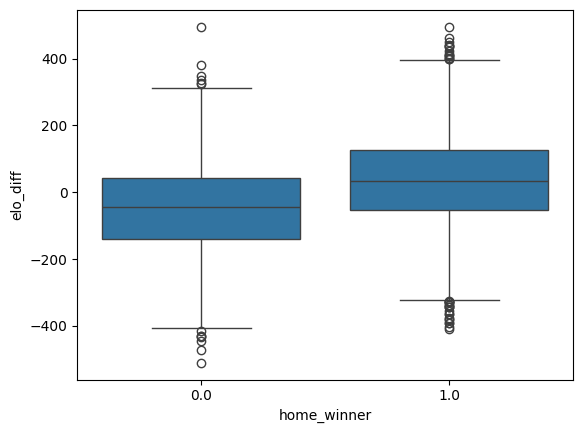

In [38]:
sns.boxplot(x='home_winner', y='elo_diff', data=nfl_df)

In [39]:
target_col = "home_winner"
all_cols = nfl_df.columns[24:].drop('Home_Team_away').tolist()
print(all_cols)

categorical_cols = []

numerical_cols = all_cols


# Boxplots of all num columns
"""
for col in numerical_cols:
    sns.boxplot(x=X_train[col])
    plt.show()
"""

nfl_df = nfl_df.dropna(subset=[target_col])

num_wins = (nfl_df['home_winner'] == 1).sum()
num_losses = (nfl_df['home_winner'].shape[0] - num_wins)
class_weights = num_losses / num_wins
X = nfl_df[numerical_cols + categorical_cols]
y = nfl_df[target_col].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", KNNImputer(n_neighbors=3)),
            ("scaler", StandardScaler()),
        ]), numerical_cols),
    ]
)

#Forest (Best Model So Far)
"""
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=500,        # Increase the number of trees for more diversity
        random_state=42, 
        max_depth=7,             # Limit tree depth to avoid overfitting
        min_samples_split=15,    # Increase min_samples_split to reduce tree complexity
        min_samples_leaf=4,      # Increase min_samples_leaf for more generalization
    ))
])
"""

#GradientBooster (2nd)
"""
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=150,        # Use a smaller number of trees for better generalization
        random_state=42, 
        max_depth=5,             # Depth to avoid overfitting
        min_samples_split=30,    # Higher value to prevent overly deep trees
        min_samples_leaf=6,      # Higher value to reduce model complexity
        learning_rate=0.01      # Smaller learning rate to avoid overfitting
    ))
])
"""

#XGBoost
xgboost_classifier = xgb.XGBClassifier(
        n_estimators=700,
        max_depth=4,
        learning_rate=0.01706675223214993,
        subsample=0.7640307727051777,
        colsample_bytree=0.8994869541803375,
        gamma=3.3490721414012086,
        min_child_weight=8,
        random_state=42,
        eval_metric="logloss"
    )

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", xgboost_classifier)
])

#GridSearch For Forest
"""
param_grid = {
    'classifier__n_estimators': [100, 300, 500],  # Number of trees in the forest (more trees tend to improve accuracy)
    'classifier__max_depth': [5, 10, 20],  # Depth of the trees; None allows unlimited depth
    'classifier__min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'classifier__min_samples_leaf': [1, 2, 4],  # Minimum number of samples required to be at a leaf node
    'classifier__max_features': ['sqrt', 'log2'],  # Number of features to consider when looking for the best split
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)
"""

#RandomizedSearch For Forest
"""
param_dist = {
    'classifier__n_estimators': [100, 300, 500],  # Number of trees in the forest
    'classifier__max_depth': [10, 20, 30, None],  # Depth of trees (None allows unlimited depth)
    'classifier__min_samples_split': [2, 5, 10],  # Number of samples required to split a node
    'classifier__min_samples_leaf': [1, 2, 4],  # Number of samples required at a leaf node
    'classifier__max_features': ['sqrt', 'log2'],  # Number of features to consider per split
    'classifier__bootstrap': [True, False]  # Whether to use bootstrap sampling
}

random_search = RandomizedSearchCV(pipeline, param_distributions=param_dist, n_iter=20, cv=5, n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)

print("Best parameters found: ", random_search.best_params_)

# Evaluate the new model
train_accuracy = random_search.best_estimator_.score(X_train, y_train)
test_accuracy = random_search.best_estimator_.score(X_test, y_test)
cross_val_scores = cross_val_score(random_search.best_estimator_, X, y, cv=5, scoring="accuracy")

print(f"Train Accuracy: {train_accuracy:.3f}")
print(f"Test Accuracy: {test_accuracy:.3f}")
print(f"Cross-validated accuracy: {scores.mean():.3f} ± {scores.std():.3f}")
"""

#GridSearch For GradientBooster
"""
param_grid = {
    "classifier__n_estimators": [50, 100, 200],
    "classifier__max_depth": [3, 5, 7],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)
"""

#GridSearch For XGBoost
"""
param_grid = {
    'classifier__n_estimators': [50, 100, 200],  # Number of trees
    'classifier__max_depth': [3, 5, 7],           # Depth of each tree
    'classifier__learning_rate': [0.01, 0.05, 0.1],  # Learning rate
    'classifier__subsample': [0.8, 1.0],          # Fraction of samples used per tree
    'classifier__colsample_bytree': [0.8, 1.0],   # Fraction of features used per tree
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)

best_model = grid_search.best_estimator_

train_accuracy = best_model.score(X_train, y_train)
test_accuracy = best_model.score(X_test, y_test)
"""

#hyperopt For Forest
"""
space = {
    'classifier__n_estimators': hp.choice('n_estimators', [50, 100, 200]),
    'classifier__max_depth': hp.choice('max_depth', [10, 20, None]),
    'classifier__min_samples_split': hp.choice('min_samples_split', [2, 5, 10]),
    'classifier__min_samples_leaf': hp.choice('min_samples_leaf', [1, 2, 4]),
    'classifier__max_features': hp.choice('max_features', [None, 'sqrt', 'log2'])
}

def objective(params):
    pipeline.set_params(**params)
    score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy').mean()
    return -score

trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=50, trials=trials)

print("Best parameters:", best)
"""

#hyperopt for XGBoost
"""
space = {
    'classifier__n_estimators': hp.choice('n_estimators', [150, 300, 500, 700]),
    'classifier__max_depth': hp.choice('max_depth', [4, 5, 6]),
    'classifier__learning_rate': hp.uniform('learning_rate', 0.005, 0.02),
    'classifier__subsample': hp.uniform('subsample', 0.7, 0.9),
    'classifier__colsample_bytree': hp.uniform('colsample_bytree', 0.7, 0.9),
    'classifier__gamma': hp.uniform('gamma', 2, 4),
    'classifier__min_child_weight': hp.choice('min_child_weight', [8, 10, 12])
}

def objective(params):
    pipeline.set_params(**params)
    score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy').mean()
    return -score

trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=50, trials=trials)
"""

# For GradBoost and Forest

pipeline.fit(X_train, y_train)

train_accuracy = pipeline.score(X_train, y_train)
test_accuracy = pipeline.score(X_test, y_test)

print(f"Train Accuracy: {train_accuracy:.3f}")
print(f"Test Accuracy: {test_accuracy:.3f}")

scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
print(f"Cross-validated accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

predictions = pipeline.predict(X_test)

print(classification_report(y_test, predictions))

fitted_classifier = pipeline.named_steps["classifier"]
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

thresholds = np.sort(fitted_classifier.feature_importances_)

for thresh in thresholds:
    selection = SelectFromModel(fitted_classifier, threshold=thresh, prefit=True)
    select_X_train = selection.transform(X_train_transformed)
    selection_model = clone(fitted_classifier)
    selection_model.fit(select_X_train, y_train)
    
    select_X_test = selection.transform(X_test_transformed)
    predictions = selection_model.predict(select_X_test)
    accuracy = accuracy_score(y_test, predictions)
    print("Thresh=%.3f, n=%d, Accuracy: %.2f%%" % (thresh, select_X_train.shape[1], accuracy*100.0))

['overall_wins(home)', 'overall_losses(home)', 'home_wins(home)', 'home_losses(home)', 'road_wins(home)', 'road_losses(home)', 'overall_wins(away)', 'overall_losses(away)', 'home_wins(away)', 'home_losses(away)', 'road_wins(away)', 'road_losses(away)', 'elo_home', 'elo_away', 'Home_Score', 'Away_Score', 'Offense_Total_Yrds', 'Offense_Pass_Yrds', 'Offense_Rush_Yrds', 'Turnovers_Lost', 'Total_Yrds_Allowed', 'Pass_Yrds_Allowed', 'Rush_Yrds_Allowed', 'Turnovers_Gained', 'Offense_Expected_Points', 'Defense_Expected_Points', 'Spteams_Expected_Points', 'Home_Score_away', 'Away_Score_away', 'Offense_Total_Yrds_away', 'Offense_Pass_Yrds_away', 'Offense_Rush_Yrds_away', 'Turnovers_Lost_away', 'Total_Yrds_Allowed_away', 'Pass_Yrds_Allowed_away', 'Rush_Yrds_Allowed_away', 'Turnovers_Gained_away', 'Offense_Expected_Points_away', 'Defense_Expected_Points_away', 'Spteams_Expected_Points_away', 'turnover_differential', 'Expected_Pass_Yrds', 'Expected_Pass_Yrds_away', 'Expected_Rush_Yrds', 'Expected_Ru

In [40]:

best_params = {
    'classifier__n_estimators': [300, 500, 700][best['n_estimators']],
    'classifier__max_depth': [4, 5, 6][best['max_depth']],
    'classifier__min_child_weight': [8, 10, 12][best['min_child_weight']],
    'classifier__learning_rate': best['learning_rate'],
    'classifier__subsample': best['subsample'],
    'classifier__colsample_bytree': best['colsample_bytree'],
    'classifier__gamma': best['gamma'],
}
print("Best converted parameters:", best_params)


NameError: name 'best' is not defined

In [1]:
!jupyter nbconvert --to script NFLIQ.ipynb

[NbConvertApp] Converting notebook NFLIQ.ipynb to script
[NbConvertApp] Writing 27921 bytes to NFLIQ.py
